<a href="https://colab.research.google.com/github/Marina4ij/dz3/blob/main/dz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import glob

csv_files = glob.glob("./CICIDS2017_CSVs/*.csv")
for f in csv_files[:3]:  # Проверяем первые 3 файла
    print(f"\n{'='*60}")
    print(f"Файл: {f}")
    df = pd.read_csv(f, nrows=2, low_memory=False)
    print(f"Колонки ({len(df.columns)}):")
    for i, col in enumerate(df.columns):
        print(f"  [{i:2d}] '{col}' (repr: {repr(col)})")


Файл: ./CICIDS2017_CSVs/Wednesday-workingHours.pcap_ISCX.csv
Колонки (85):
  [ 0] 'Flow ID' (repr: 'Flow ID')
  [ 1] ' Source IP' (repr: ' Source IP')
  [ 2] ' Source Port' (repr: ' Source Port')
  [ 3] ' Destination IP' (repr: ' Destination IP')
  [ 4] ' Destination Port' (repr: ' Destination Port')
  [ 5] ' Protocol' (repr: ' Protocol')
  [ 6] ' Timestamp' (repr: ' Timestamp')
  [ 7] ' Flow Duration' (repr: ' Flow Duration')
  [ 8] ' Total Fwd Packets' (repr: ' Total Fwd Packets')
  [ 9] ' Total Backward Packets' (repr: ' Total Backward Packets')
  [10] 'Total Length of Fwd Packets' (repr: 'Total Length of Fwd Packets')
  [11] ' Total Length of Bwd Packets' (repr: ' Total Length of Bwd Packets')
  [12] ' Fwd Packet Length Max' (repr: ' Fwd Packet Length Max')
  [13] ' Fwd Packet Length Min' (repr: ' Fwd Packet Length Min')
  [14] ' Fwd Packet Length Mean' (repr: ' Fwd Packet Length Mean')
  [15] ' Fwd Packet Length Std' (repr: ' Fwd Packet Length Std')
  [16] 'Bwd Packet Length Max'

проверка структуры CSV

CICIDS2017 / CSE-CIC-IDS2018 — стандартные датасеты от Канадского института кибербезопасности. Содержат нормальный сетевой трафик и множество видов атак (DDoS, брутфорс, SQL-инъекции и т.д.).
Где найти: Сайт UNB (Canadian Institute for Cybersecurity) или Kaggle.
CICIDS2017: https://www.unb.ca/cic/datasets/ids-2017.html (CSV-файлы с сетевым трафиком и атаками)

Создаёт 4 таблицы с использованием всех требуемых типов данных:
attack_types — справочник атак (INTEGER, TEXT, BOOLEAN)
protocols — справочник протоколов (INTEGER, TEXT)
network_flows — основная таблица потоков (TEXT, INTEGER, REAL, DATE, DATETIME, BOOLEAN)
daily_traffic_summary — агрегатная таблица (DATE, INTEGER, BIGINT, TEXT, REAL, DATETIME)
Импортирует данные из всех CSV-файлов CICIDS2017 с обработкой:
Пробелов в названиях колонок
Битых символов в кодировке (latin-1)
Значений Infinity и NaN
Пустых IP-адресов
Лимита SQLite на количество переменных

[1/8] Построение: распределение типов атак...


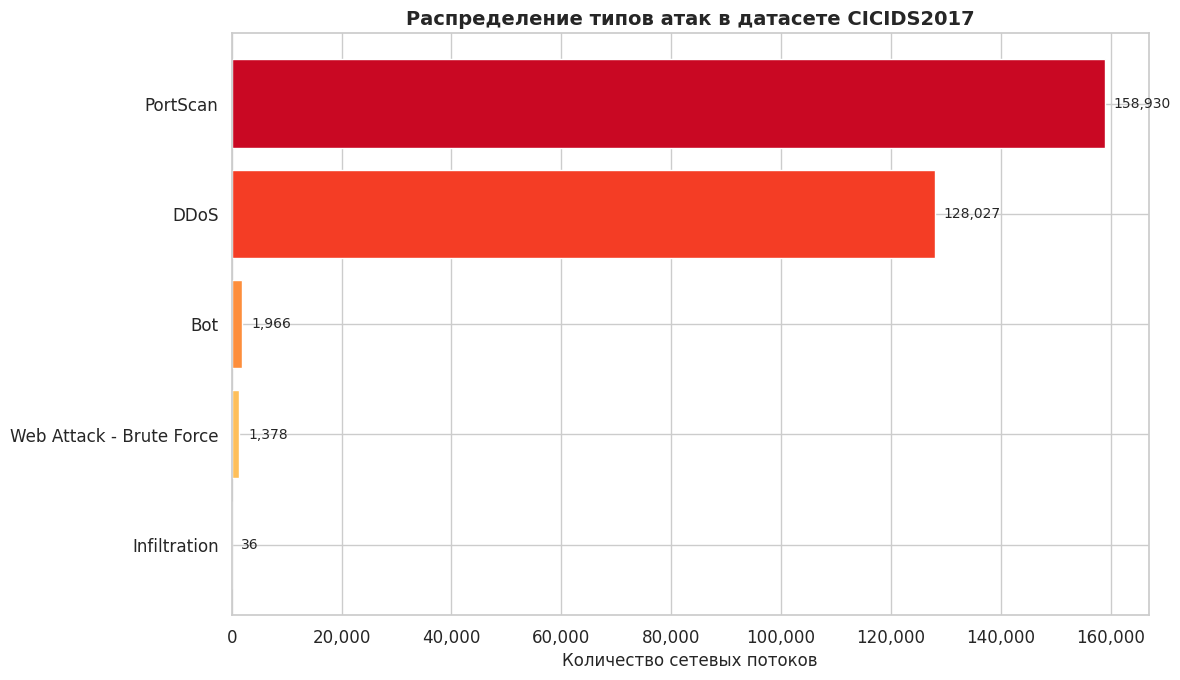

[2/8] Построение: соотношение трафика...


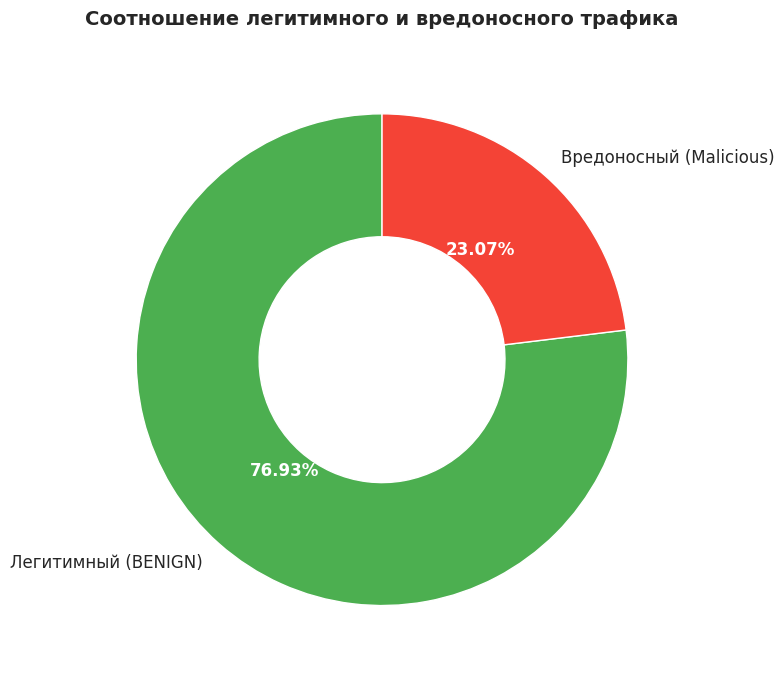

[3/8] Построение: динамика атак по дням...


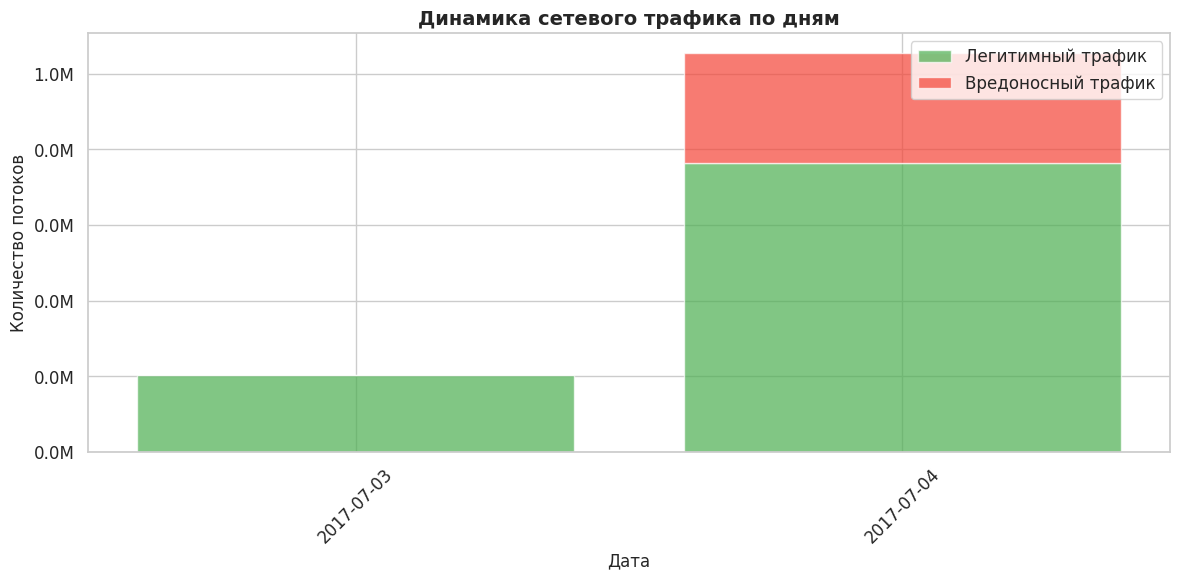

[4/8] Построение: топ IP-адресов атакующих...


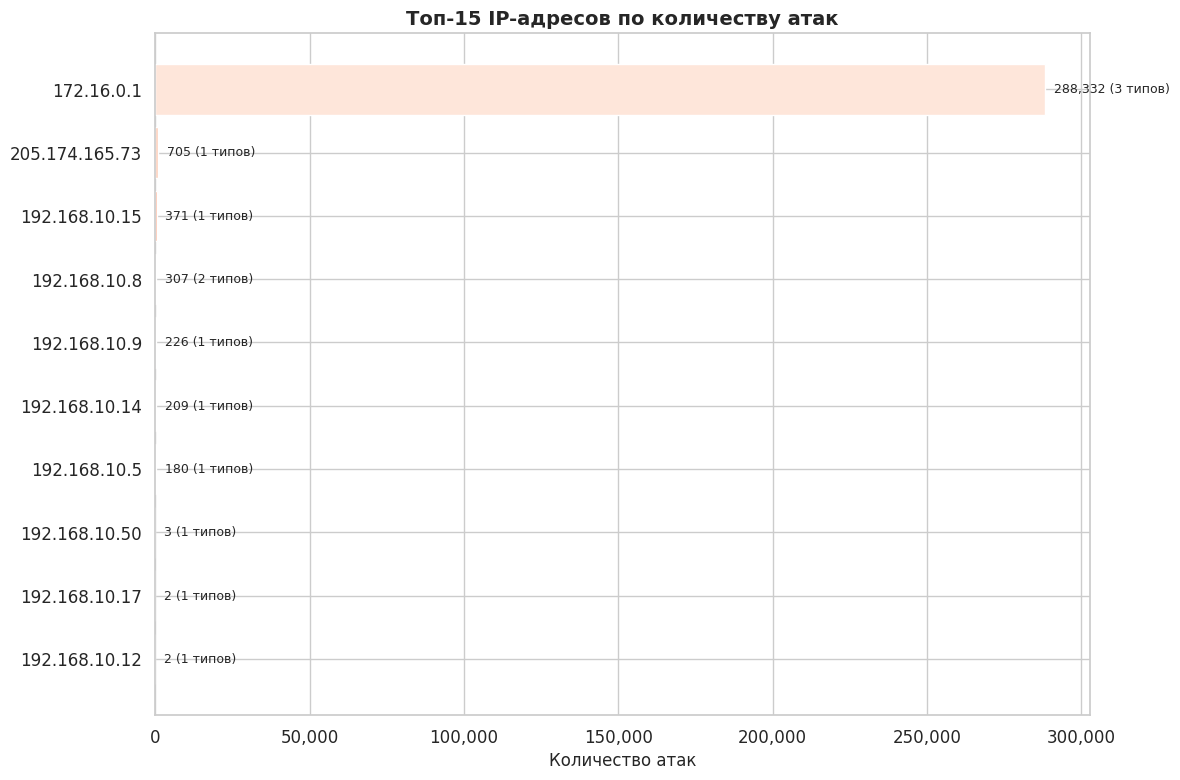

[5/8] Построение: распределение по портам...


/tmp/ipykernel_2065/2059406239.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ports, x='port_label', y='cnt', palette='viridis', ax=ax)


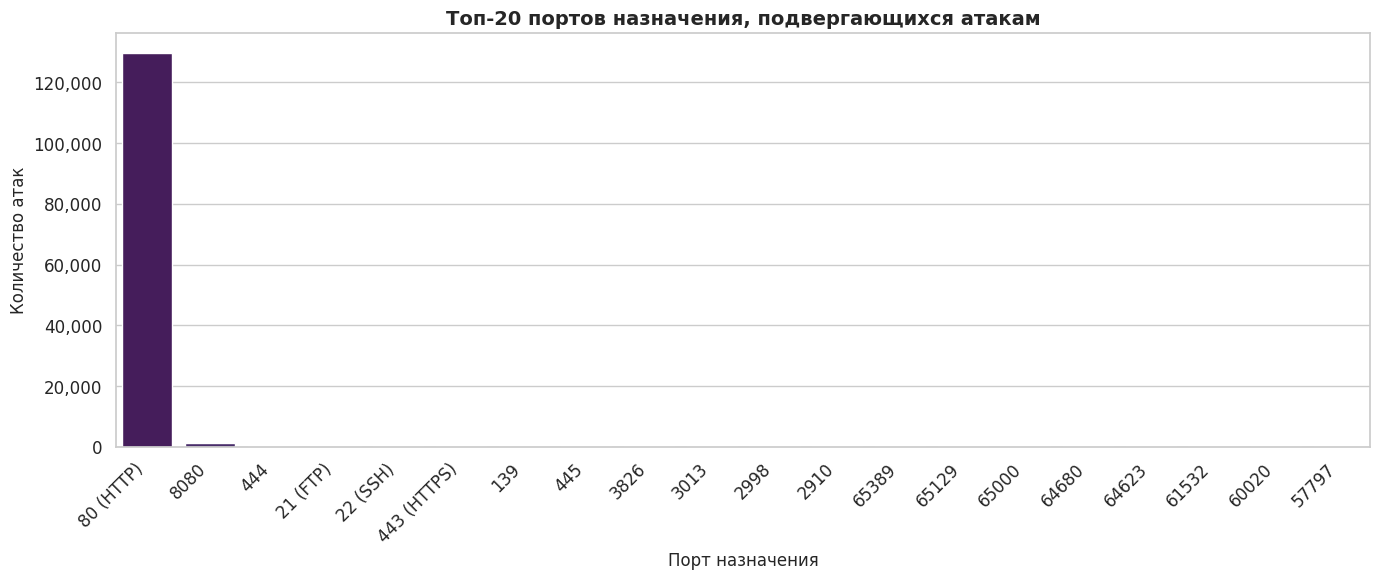

[6/8] Построение: тепловая карта активности...
  [WARN] Нет данных для тепловой карты. Пропускаем.
[7/8] Построение: распределение длительности потоков...


/tmp/ipykernel_2065/2059406239.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_duration, x='category', y='log_duration',


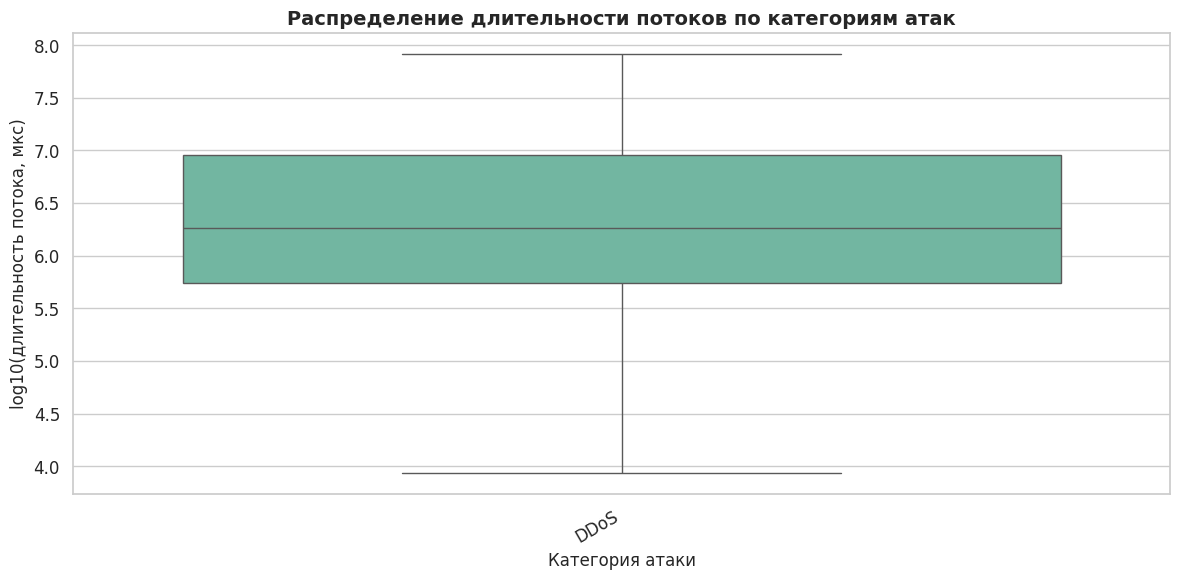

[8/8] Построение: итоговый дашборд...


/tmp/ipykernel_2065/2059406239.py:274: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y='name', x='cnt', palette='Reds_r', ax=ax2)
/tmp/ipykernel_2065/2059406239.py:280: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_duration, x='category', y='log_duration',


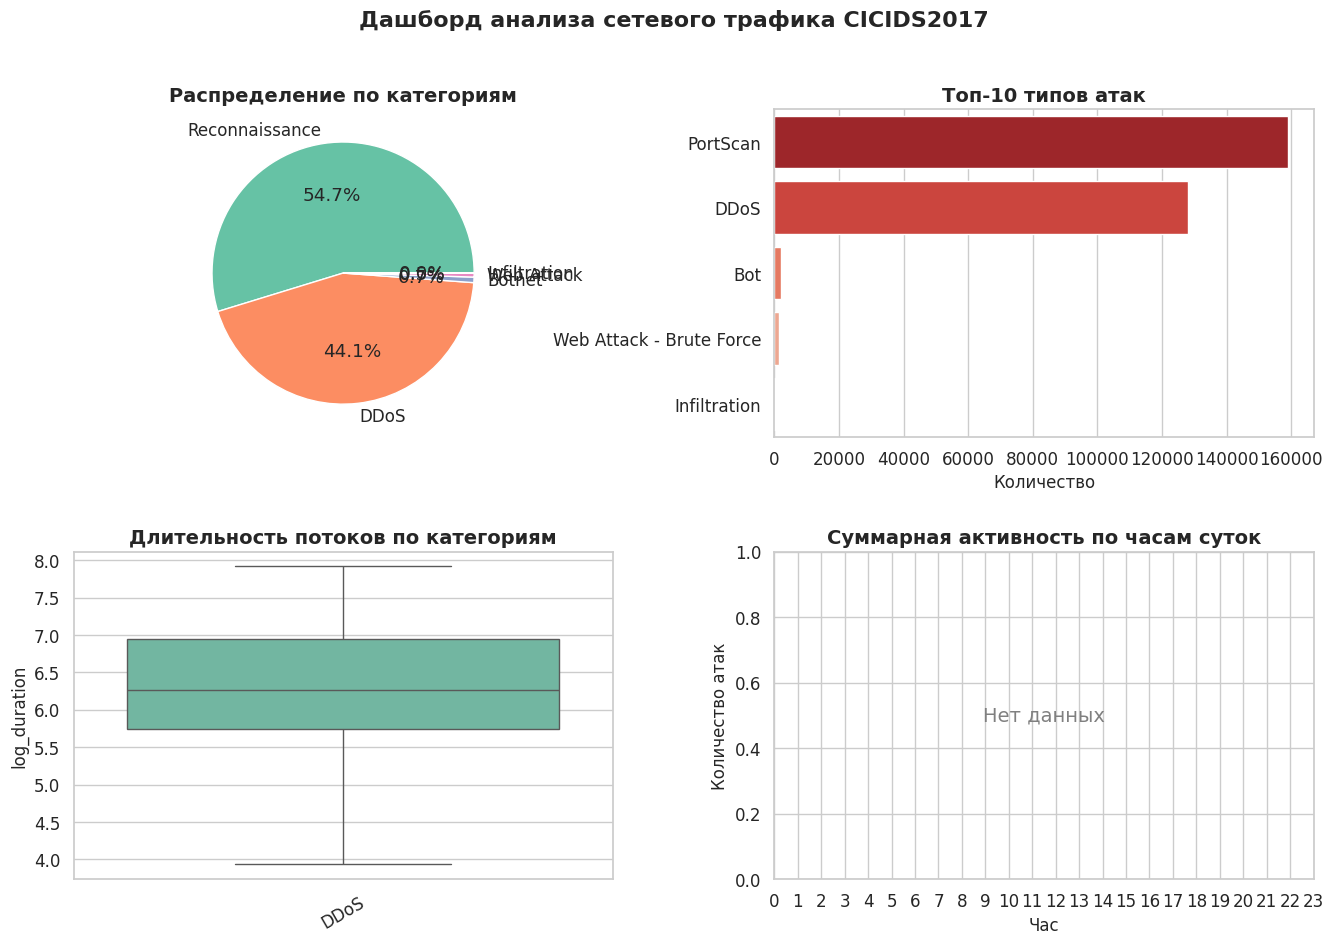


[DONE] Все визуализации построены и сохранены!


In [27]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Для Jupyter/Colab - раскомментируйте следующую строку:
# get_ipython().run_line_magic('matplotlib', 'inline')

# Настройка стиля графиков
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Подключение к базе данных
DB_NAME = "cicids2017_normalized.db"
conn = sqlite3.connect(DB_NAME)

def query_to_df(sql):
    return pd.read_sql_query(sql, conn)

# =====================================================================
# 1. РАСПРЕДЕЛЕНИЕ ТИПОВ АТАК
# =====================================================================
%matplotlib inline
print("[1/8] Построение: распределение типов атак...")

df_attacks = query_to_df('''
    SELECT at.name, at.category, COUNT(*) as cnt
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1
    GROUP BY at.name
    ORDER BY cnt DESC
''')

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("YlOrRd_r", n_colors=len(df_attacks))
bars = ax.barh(df_attacks['name'], df_attacks['cnt'], color=colors)
ax.set_xlabel('Количество сетевых потоков')
ax.set_title('Распределение типов атак в датасете CICIDS2017', fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, df_attacks['cnt']):
    ax.text(val + max(df_attacks['cnt']) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('01_attack_types_distribution.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ: показываем график

# =====================================================================
# 2. СООТНОШЕНИЕ ТРАФИКА
# =====================================================================
print("[2/8] Построение: соотношение трафика...")

df_traffic_ratio = query_to_df('''
    SELECT
        CASE WHEN is_malicious = 0 THEN 'Легитимный (BENIGN)'
             ELSE 'Вредоносный (Malicious)' END as type,
        COUNT(*) as cnt
    FROM network_flows
    GROUP BY is_malicious
''')

fig, ax = plt.subplots(figsize=(8, 8))
colors_pie = ['#4CAF50', '#F44336']
wedges, texts, autotexts = ax.pie(
    df_traffic_ratio['cnt'],
    labels=df_traffic_ratio['type'],
    autopct='%1.2f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.set_title('Соотношение легитимного и вредоносного трафика', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('02_traffic_ratio.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ

# =====================================================================
# 3. ДИНАМИКА АТАК ПО ДНЯМ
# =====================================================================
print("[3/8] Построение: динамика атак по дням...")

df_daily = query_to_df('''
    SELECT flow_date,
           COUNT(*) as total_flows,
           SUM(is_malicious) as malicious_flows,
           SUM(CASE WHEN is_malicious = 0 THEN 1 ELSE 0 END) as benign_flows
    FROM network_flows
    GROUP BY flow_date
    ORDER BY flow_date
''')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(df_daily['flow_date'], df_daily['benign_flows'],
        label='Легитимный трафик', color='#4CAF50', alpha=0.7)
ax1.bar(df_daily['flow_date'], df_daily['malicious_flows'],
        bottom=df_daily['benign_flows'],
        label='Вредоносный трафик', color='#F44336', alpha=0.7)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество потоков')
ax1.set_title('Динамика сетевого трафика по дням', fontweight='bold')
ax1.legend(loc='upper right')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1e6):.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('03_daily_traffic_dynamics.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ

# =====================================================================
# 4. ТОП IP-АДРЕСОВ
# =====================================================================
print("[4/8] Построение: топ IP-адресов атакующих...")

df_top_ips = query_to_df('''
    SELECT src_ip, COUNT(*) as attack_count,
           COUNT(DISTINCT label) as attack_types
    FROM network_flows
    WHERE is_malicious = 1
    GROUP BY src_ip
    ORDER BY attack_count DESC
    LIMIT 15
''')

fig, ax = plt.subplots(figsize=(12, 8))
colors_ip = sns.color_palette("Reds", n_colors=len(df_top_ips))
bars = ax.barh(df_top_ips['src_ip'], df_top_ips['attack_count'], color=colors_ip)
ax.set_xlabel('Количество атак')
ax.set_title('Топ-15 IP-адресов по количеству атак', fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val, types in zip(bars, df_top_ips['attack_count'], df_top_ips['attack_types']):
    ax.text(val + max(df_top_ips['attack_count']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,} ({types} типов)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('04_top_attacker_ips.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ

# =====================================================================
# 5. РАСПРЕДЕЛЕНИЕ ПО ПОРТАМ
# =====================================================================
print("[5/8] Построение: распределение по портам...")

df_ports = query_to_df('''
    SELECT dst_port, COUNT(*) as cnt
    FROM network_flows
    WHERE is_malicious = 1
    GROUP BY dst_port
    ORDER BY cnt DESC
    LIMIT 20
''')

port_names = {80: 'HTTP', 443: 'HTTPS', 22: 'SSH', 21: 'FTP',
              53: 'DNS', 25: 'SMTP', 23: 'Telnet', 3389: 'RDP'}
df_ports['port_label'] = df_ports['dst_port'].apply(
    lambda p: f"{p} ({port_names[p]})" if p in port_names else str(p)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_ports, x='port_label', y='cnt', palette='viridis', ax=ax)
ax.set_xlabel('Порт назначения')
ax.set_ylabel('Количество атак')
ax.set_title('Топ-20 портов назначения, подвергающихся атакам', fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('05_attacked_ports.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ

# =====================================================================
# 6. ТЕПЛОВАЯ КАРТА
# =====================================================================
print("[6/8] Построение: тепловая карта активности...")

df_raw = query_to_df('''
    SELECT flow_timestamp, flow_date
    FROM network_flows
    WHERE is_malicious = 1
''')

df_raw['flow_timestamp'] = pd.to_datetime(df_raw['flow_timestamp'], errors='coerce')
df_raw = df_raw.dropna(subset=['flow_timestamp'])
df_raw['flow_date'] = df_raw['flow_timestamp'].dt.date
df_raw['hour'] = df_raw['flow_timestamp'].dt.hour.astype(int)

df_heatmap = df_raw.groupby(['flow_date', 'hour']).size().reset_index(name='attacks')

if df_heatmap.empty:
    print("  [WARN] Нет данных для тепловой карты. Пропускаем.")
else:
    heatmap_data = df_heatmap.pivot_table(
        index='flow_date', columns='hour', values='attacks', fill_value=0
    )
    all_hours = range(24)
    heatmap_data = heatmap_data.reindex(columns=all_hours, fill_value=0)

    if heatmap_data.empty or heatmap_data.size == 0:
        print("  [WARN] Матрица heatmap пуста. Пропускаем.")
    else:
        fig, ax = plt.subplots(figsize=(14, 5))
        sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False,
                    cbar_kws={'label': 'Количество атак'}, ax=ax)
        ax.set_xlabel('Час суток')
        ax.set_ylabel('Дата')
        ax.set_title('Тепловая карта вредоносной активности по времени', fontweight='bold')
        plt.tight_layout()
        plt.savefig('06_activity_heatmap.png', bbox_inches='tight')
        plt.show()  # ИСПРАВЛЕНИЕ
        print("  [OK] Тепловая карта сохранена")

# =====================================================================
# 7. РАСПРЕДЕЛЕНИЕ ДЛИТЕЛЬНОСТИ
# =====================================================================
print("[7/8] Построение: распределение длительности потоков...")

df_duration = query_to_df('''
    SELECT at.category, nf.flow_duration
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1 AND nf.flow_duration > 0
    LIMIT 50000
''')

df_duration['log_duration'] = np.log10(df_duration['flow_duration'] + 1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_duration, x='category', y='log_duration',
            palette='Set2', ax=ax, showfliers=False)
ax.set_xlabel('Категория атаки')
ax.set_ylabel('log10(длительность потока, мкс)')
ax.set_title('Распределение длительности потоков по категориям атак', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('07_flow_duration_distribution.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ

# =====================================================================
# 8. ДАШБОРД
# =====================================================================
print("[8/8] Построение: итоговый дашборд...")

df_categories = query_to_df('''
    SELECT at.category, COUNT(*) as cnt
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1
    GROUP BY at.category
    ORDER BY cnt DESC
''')

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(df_categories['cnt'], labels=df_categories['category'],
        autopct='%1.1f%%', colors=sns.color_palette('Set2'))
ax1.set_title('Распределение по категориям', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
top10 = df_attacks.head(10)
sns.barplot(data=top10, y='name', x='cnt', palette='Reds_r', ax=ax2)
ax2.set_title('Топ-10 типов атак', fontweight='bold')
ax2.set_xlabel('Количество')
ax2.set_ylabel('')

ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df_duration, x='category', y='log_duration',
            palette='Set2', ax=ax3, showfliers=False)
ax3.set_title('Длительность потоков по категориям', fontweight='bold')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=30)

ax4 = fig.add_subplot(gs[1, 1])

if not df_heatmap.empty:
    hourly = df_heatmap.groupby('hour')['attacks'].sum().reset_index()
    hourly['hour'] = hourly['hour'].astype(int)
    hourly['attacks'] = hourly['attacks'].astype(int)

    all_hours = pd.DataFrame({'hour': range(24)})
    hourly = all_hours.merge(hourly, on='hour', how='left').fillna(0)
    hourly['attacks'] = hourly['attacks'].astype(int)

    ax4.plot(hourly['hour'], hourly['attacks'], marker='o',
             color='#E74C3C', linewidth=2, markersize=6)
    ax4.fill_between(hourly['hour'], hourly['attacks'], alpha=0.3, color='#E74C3C')
else:
    ax4.text(0.5, 0.5, 'Нет данных', ha='center', va='center',
             transform=ax4.transAxes, fontsize=14, color='gray')

ax4.set_title('Суммарная активность по часам суток', fontweight='bold')
ax4.set_xlabel('Час')
ax4.set_ylabel('Количество атак')
ax4.set_xticks(range(0, 24))

fig.suptitle('Дашборд анализа сетевого трафика CICIDS2017',
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('08_dashboard.png', bbox_inches='tight')
plt.show()  # ИСПРАВЛЕНИЕ

conn.close()

print("\n[DONE] Все визуализации построены и сохранены!")

In [26]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("cicids2017_normalized.db")
cursor = conn.cursor()

# Получаем реальные значения label
cursor.execute("SELECT DISTINCT label FROM network_flows")
real_labels = [row[0] for row in cursor.fetchall()]

print("Реальные значения label в БД:")
for label in real_labels:
    print(f"  '{label}'")

# Создаём маппинг: реальное название -> attack_id
# (замените на основе вывода диагностики)
label_mapping = {
    'BENIGN': 1,
    'DDoS': 2,
    'PortScan': 3,
    'Bot': 4,
    'Infiltration': 5,
    'Web Attack - Brute Force': 6,
    'Web Attack - XSS': 7,
    'Web Attack - Sql Injection': 8,
    'FTP-Patator': 9,
    'SSH-Patator': 10,
    'DoS slowloris': 11,
    'DoS Slowhttptest': 12,
    'DoS Hulk': 13,
    'DoS GoldenEye': 14,
    'Heartbleed': 15,
}

# Если есть битые символы, добавляем варианты
for label in real_labels:
    if label not in label_mapping:
        # Пробуем очистить от битых символов
        clean_label = label.replace('', '-').replace('\x96', '-').strip()
        if clean_label in label_mapping:
            label_mapping[label] = label_mapping[clean_label]
            print(f"  Маппинг: '{label}' -> '{clean_label}'")

# Обновляем attack_id и is_malicious
for label, attack_id in label_mapping.items():
    cursor.execute("""
        UPDATE network_flows
        SET attack_id = ?,
            is_malicious = (SELECT is_malicious FROM attack_types WHERE attack_id = ?)
        WHERE label = ?
    """, (attack_id, attack_id, label))

conn.commit()

# Проверяем результат
cursor.execute("""
    SELECT is_malicious, COUNT(*) as cnt
    FROM network_flows
    GROUP BY is_malicious
""")
print("\nПосле исправления:")
for row in cursor.fetchall():
    label = "Вредоносный" if row[0] == 1 else "Легитимный"
    print(f"  {label}: {row[1]:,}")

conn.close()
print("\n[OK] Маппинг исправлен. Перезапустите визуализацию.")

Реальные значения label в БД:
  'BENIGN'
  'DDoS'
  'PortScan'
  'Bot'
  'nan'
  'Infiltration'
  'Web Attack - Brute Force'

После исправления:
  Легитимный: 968,094
  Вредоносный: 290,337

[OK] Маппинг исправлен. Перезапустите визуализацию.


In [25]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("cicids2017_normalized.db")

print("="*60)
print("ДИАГНОСТИКА БАЗЫ ДАННЫХ")
print("="*60)

# 1. Общее количество записей
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM network_flows")
total = cursor.fetchone()[0]
print(f"\n1. Всего записей в network_flows: {total:,}")

if total == 0:
    print("   [ERROR] База пуста! Импорт не прошёл.")
else:
    # 2. Распределение по is_malicious
    cursor.execute("""
        SELECT is_malicious, COUNT(*) as cnt
        FROM network_flows
        GROUP BY is_malicious
    """)
    print("\n2. Распределение по is_malicious:")
    for row in cursor.fetchall():
        label = "Вредоносный" if row[0] == 1 else "Легитимный"
        print(f"   {label}: {row[1]:>12,} ({100*row[1]/total:.2f}%)")

    # 3. Уникальные значения label (оригинальные названия из CSV)
    cursor.execute("""
        SELECT label, COUNT(*) as cnt
        FROM network_flows
        GROUP BY label
        ORDER BY cnt DESC
        LIMIT 20
    """)
    print("\n3. Топ-20 уникальных значений label:")
    for row in cursor.fetchall():
        print(f"   '{row[0]}' -> {row[1]:>10,}")

    # 4. Проверка flow_timestamp
    cursor.execute("""
        SELECT flow_timestamp, COUNT(*) as cnt
        FROM network_flows
        WHERE flow_timestamp IS NOT NULL AND flow_timestamp != 'NaT'
        LIMIT 5
    """)
    print("\n4. Примеры flow_timestamp:")
    for row in cursor.fetchall():
        print(f"   '{row[0]}' -> {row[1]:>10,}")

    # 5. Проверка flow_date
    cursor.execute("""
        SELECT flow_date, COUNT(*) as cnt
        FROM network_flows
        GROUP BY flow_date
        ORDER BY flow_date
    """)
    print("\n5. Распределение по flow_date:")
    for row in cursor.fetchall():
        print(f"   {row[0]} -> {row[1]:>10,}")

conn.close()

ДИАГНОСТИКА БАЗЫ ДАННЫХ

1. Всего записей в network_flows: 1,258,431

2. Распределение по is_malicious:
   Легитимный:    1,258,431 (100.00%)

3. Топ-20 уникальных значений label:
   'BENIGN' ->    968,091
   'PortScan' ->    158,930
   'DDoS' ->    128,027
   'Bot' ->      1,966
   'Web Attack - Brute Force' ->      1,378
   'Infiltration' ->         36
   'nan' ->          3

4. Примеры flow_timestamp:
   '2017-07-03 08:55:58' ->    203,349

5. Распределение по flow_date:
   2017-07-03 ->    203,349
   2017-07-04 ->  1,055,082
